In [67]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [68]:
import os
import sys
module_path = os.path.abspath(os.path.join('../../'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [69]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import seaborn as sns
import matplotlib.pyplot as plt
from machines.predictions.svr_prediction import SVR_Prediction
from machines.enums import SvrKernelEnum
from preprocesses.preprocess import Preprocess
from preprocesses.enums import TransformEnum, TypeFileEnum, StandardScaleEnum
from metrics.error_metric import ErrorMetric
from metrics.enums import MetricEnum, PlotLegends
import numpy as np

Read the file and prepare data for SVR

In [70]:
file_csv = '../../../data/phen/original/obregon_phenotypic_original_151617.csv'
df = pd.read_csv(file_csv, header=0)
df.head()

,TGW,HI,BM,NDVI_VG1,NDVI_VG2,NDVI_VG3,NDVI_VG4,NDVI_VG,NDVI_GF1,NDVI_GF2,...,NDVI_UAV_1,NDVI_UAV_2,NDVI_UAV_3,NDVI_UAV_4,NDVI_UAV_5,CT_UAV_1,CT_UAV_2,CT_UAV_3,CT_UAV_4,YLD
0,40.510542,0.493706,1252.841830,0.171286,0.176257,0.375381,0.757965,0.444839,0.776698,0.744168,...,0.499727,0.458816,0.659201,0.754407,0.873936,25.451605,24.184386,24.083716,31.700124,617.4453
1,37.094174,0.492329,1403.919849,0.170764,0.214652,0.409778,0.782313,0.469060,0.770800,0.720762,...,0.486031,0.499782,0.693321,0.777470,0.878137,25.482403,24.005464,23.580308,31.270182,689.6464
2,44.201750,0.498393,1376.809117,0.156686,0.169272,0.334773,0.738150,0.417022,0.751064,0.667258,...,0.462325,0.431861,0.610026,0.708450,0.875478,25.643851,24.291071,24.444127,32.008681,687.2559
3,32.876596,0.516203,1234.698326,0.165603,0.190059,0.332481,0.675919,0.406757,0.728636,0.643564,...,0.413157,0.405293,0.560463,0.652515,0.844511,26.120276,24.171371,25.492758,34.282378,636.4969
4,41.374175,0.481962,1279.299001,0.187345,0.221703,0.429379,0.778879,0.472912,0.755801,0.731699,...,0.492748,0.494245,0.653331,0.738558,0.882129,25.619695,23.807970,23.970900,31.579817,616.5022


In [71]:
# Get the head of varaibles

print(list[df.columns])
x_cols = ['NDVI_VG1', 'NDVI_VG2', 'NDVI_VG3', 'NDVI_VG4',
       'NDVI_VG', 'NDVI_GF1', 'NDVI_GF2', 'NDVI_GF3', 'NDVI_GF4', 'NDVI_GF',
       'NDVI_UAV_1', 'NDVI_UAV_2', 'NDVI_UAV_3', 'NDVI_UAV_4', 'NDVI_UAV_5',
       'CT_UAV_1', 'CT_UAV_2', 'CT_UAV_3', 'CT_UAV_4']
yield_col = 'YLD'
print(x_cols)

list[Index(['TGW', 'HI', 'BM', 'NDVI_VG1', 'NDVI_VG2', 'NDVI_VG3', 'NDVI_VG4',
       'NDVI_VG', 'NDVI_GF1', 'NDVI_GF2', 'NDVI_GF3', 'NDVI_GF4', 'NDVI_GF',
       'NDVI_UAV_1', 'NDVI_UAV_2', 'NDVI_UAV_3', 'NDVI_UAV_4', 'NDVI_UAV_5',
       'CT_UAV_1', 'CT_UAV_2', 'CT_UAV_3', 'CT_UAV_4', 'YLD'],
      dtype='object')]
['NDVI_VG1', 'NDVI_VG2', 'NDVI_VG3', 'NDVI_VG4', 'NDVI_VG', 'NDVI_GF1', 'NDVI_GF2', 'NDVI_GF3', 'NDVI_GF4', 'NDVI_GF', 'NDVI_UAV_1', 'NDVI_UAV_2', 'NDVI_UAV_3', 'NDVI_UAV_4', 'NDVI_UAV_5', 'CT_UAV_1', 'CT_UAV_2', 'CT_UAV_3', 'CT_UAV_4']


In [72]:
ss = StandardScaler()
si = SimpleImputer( strategy='mean')
df[x_cols] = ss.fit_transform(df[x_cols])
df[x_cols] = si.fit_transform(df[x_cols])
df.head()



,TGW,HI,BM,NDVI_VG1,NDVI_VG2,NDVI_VG3,NDVI_VG4,NDVI_VG,NDVI_GF1,NDVI_GF2,...,NDVI_UAV_1,NDVI_UAV_2,NDVI_UAV_3,NDVI_UAV_4,NDVI_UAV_5,CT_UAV_1,CT_UAV_2,CT_UAV_3,CT_UAV_4,YLD
0,40.510542,0.493706,1252.841830,-0.788747,-1.096127,-1.191792,0.408816,-1.155893,0.952816,1.065848,...,-0.820190,-1.116770,-0.823039,0.316080,0.348593,-1.063136,-0.937620,-0.912799,1.055163,617.4453
1,37.094174,0.492329,1403.919849,-0.792272,-0.961421,-1.017695,0.786018,-0.941195,0.884020,0.623312,...,-0.937790,-0.830913,0.059061,0.995764,0.552691,-1.043528,-0.993309,-1.053877,0.896796,689.6464
2,44.201750,0.498393,1376.809117,-0.887363,-1.120633,-1.397326,0.101840,-1.402465,0.653816,-0.388284,...,-1.141340,-1.304860,-2.094353,-1.038305,0.423508,-0.940741,-0.904414,-0.811794,1.168818,687.2559
3,32.876596,0.516203,1234.698326,-0.827133,-1.047704,-1.408927,-0.862250,-1.493456,0.392211,-0.836265,...,-1.563518,-1.490249,-3.375699,-2.686750,-1.080967,-0.637419,-0.941671,-0.517918,2.006322,636.4969
4,41.374175,0.481962,1279.299001,-0.680275,-0.936683,-0.918486,0.732818,-0.907051,0.709069,0.830098,...,-0.880115,-0.869550,-0.974795,-0.151001,0.746635,-0.956120,-1.054778,-0.944415,1.010849,616.5022


In [73]:
pca_2 = PCA(n_components=2 , random_state=42)
df_pca_2 = pca_2.fit_transform(df[x_cols])

df_pca_2[:4]


array([[-3.74315104,  0.54315237],
       [-3.85551419, -0.55621556],
       [-3.68897144,  2.54026141],
       [-2.77889472,  5.46677849]])

In [74]:
df_2 = pd.DataFrame({"PCA1": df_pca_2[:,0],"PCA2": df_pca_2[:,1], "YLD": df[yield_col]})
df_2.head()

,PCA1,PCA2,YLD
0,-3.743151,0.543152,617.4453
1,-3.855514,-0.556216,689.6464
2,-3.688971,2.540261,687.2559
3,-2.778895,5.466778,636.4969
4,-3.578229,0.576227,616.5022


In [75]:
pca_2.explained_variance_ratio_


array([0.78710504, 0.10243118])

In [76]:
pca_2.explained_variance_ratio_.sum()


0.8895362208777055

<Axes: >

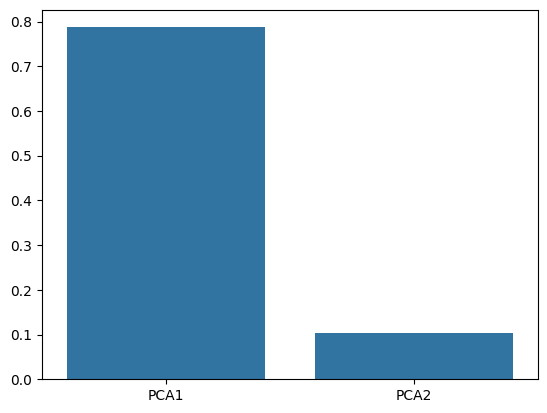

In [77]:
sns.barplot(x=['PCA1', 'PCA2'], y=pca_2.explained_variance_ratio_)

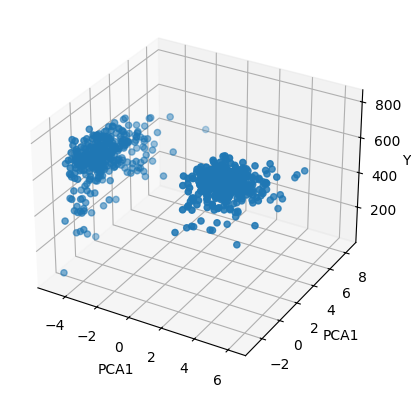

In [78]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

x = df_2['PCA1']
y = df_2['PCA2']
z = df_2['YLD']

ax.scatter(x,y,z)

ax.set_xlabel('PCA1')
ax.set_ylabel('PCA1')
ax.set_zlabel('YLD')

plt.show()


## Seleccion de varaibles

In [79]:
pca_all = PCA(n_components=len(x_cols) , random_state=42)
df_pca_all = pca_all.fit_transform(df[x_cols])

df_pca_all[:4]


array([[-3.74315104e+00,  5.43152365e-01, -2.25546585e-01,
        -1.36758197e-01,  5.17446655e-02, -7.03782961e-01,
        -2.09337902e-01, -4.79641928e-02,  1.22693850e-01,
        -1.15264860e-01, -2.87730944e-02,  1.72466906e-01,
         1.06662314e-01,  5.04617438e-02,  1.83185675e-01,
         1.08735411e-01,  1.17139057e-01,  2.44955593e-02,
         2.59577343e-02],
       [-3.85551419e+00, -5.56215561e-01,  2.58267204e-01,
        -3.79800868e-02, -7.01139160e-02, -2.07015464e-01,
         5.09938173e-01,  2.07655672e-01,  1.04494472e-02,
         6.64481842e-02,  8.48885042e-02,  2.88392464e-02,
        -2.99012063e-02,  7.13941421e-02,  6.35050149e-02,
        -1.62247187e-02, -7.62761656e-02, -5.34137576e-02,
        -8.37671011e-03],
       [-3.68897144e+00,  2.54026141e+00, -4.80260736e-02,
        -1.68467978e-01,  6.58236473e-01,  5.83652614e-01,
        -4.66780500e-02, -1.83805556e-01, -2.90151464e-02,
        -1.14764734e-01,  8.45218887e-03,  2.46018946e-01,
    

In [80]:
df_all = pd.DataFrame({
    "PCA1": df_pca_all[:,0],
    "PCA2": df_pca_all[:,1],
    "PCA3": df_pca_all[:,2],
    "PCA4": df_pca_all[:,3],
    "PCA5": df_pca_all[:,4],
    "PCA6": df_pca_all[:,5],
    "PCA7": df_pca_all[:,6],
    "PCA8": df_pca_all[:,7],
    "PCA9": df_pca_all[:,8],
    "PCA10": df_pca_all[:,9],
    "PCA11": df_pca_all[:,10],
    "PCA12": df_pca_all[:,11],
    "PCA13": df_pca_all[:,12],
    "PCA14": df_pca_all[:,13],
    "PCA15": df_pca_all[:,14],
    "PCA16": df_pca_all[:,15],
    "PCA17": df_pca_all[:,16],
    "PCA18": df_pca_all[:,17],
    "PCA19": df_pca_all[:,18],
    "YLD": df[yield_col]})
df_all.head()


,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7,PCA8,PCA9,PCA10,PCA11,PCA12,PCA13,PCA14,PCA15,PCA16,PCA17,PCA18,PCA19,YLD
0,-3.743151,0.543152,-0.225547,-0.136758,0.051745,-0.703783,-0.209338,-0.047964,0.122694,-0.115265,-0.028773,0.172467,0.106662,0.050462,0.183186,0.108735,0.117139,0.024496,0.025958,617.4453
1,-3.855514,-0.556216,0.258267,-0.037980,-0.070114,-0.207015,0.509938,0.207656,0.010449,0.066448,0.084889,0.028839,-0.029901,0.071394,0.063505,-0.016225,-0.076276,-0.053414,-0.008377,689.6464
2,-3.688971,2.540261,-0.048026,-0.168468,0.658236,0.583653,-0.046678,-0.183806,-0.029015,-0.114765,0.008452,0.246019,-0.047860,0.085007,0.114579,0.047944,0.059554,0.006606,-0.004600,687.2559
3,-2.778895,5.466778,-0.259260,-0.154423,0.649783,-0.200022,-0.116817,-0.574913,0.114144,-0.042903,0.138754,-0.090140,0.254253,-0.060111,0.024544,-0.138918,-0.110388,0.052333,-0.035774,636.4969
4,-3.578229,0.576227,-0.391074,0.046867,0.007864,0.056184,-0.248748,-0.095927,-0.341303,-0.203385,-0.091653,0.058629,-0.036793,-0.170976,0.050877,-0.048230,-0.075444,0.039881,0.027993,616.5022


In [81]:
all_pca_col = [ 
    "PCA1",
    "PCA2",
    "PCA3",
    "PCA4",
    "PCA5",
    "PCA6",
    "PCA7",
    "PCA8",
    "PCA9",
    "PCA10",
    "PCA11",
    "PCA12",
    "PCA13",
    "PCA14",
    "PCA15",
    "PCA16",
    "PCA17",
    "PCA18",
    "PCA19",
]


<Axes: >

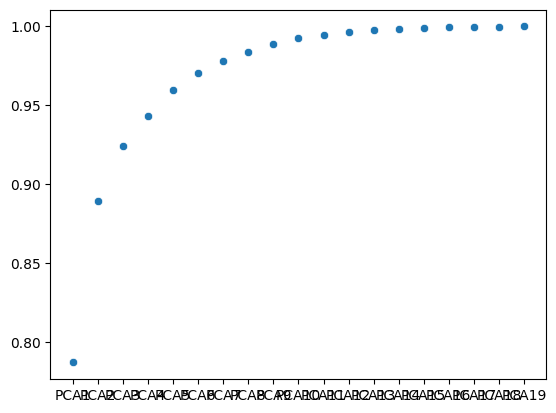

In [82]:
sns.scatterplot(x=all_pca_col, y=pca_all.explained_variance_ratio_.cumsum())

Prabajar con 5 varaibles para SVR lineal

In [83]:
svr = SVR_Prediction(kernel=SvrKernelEnum.LINEAR)
pca_all_7_columns = ["PCA1","PCA2","PCA3","PCA4","PCA5"]
# df_all[pca_all_7_columns]
# df_pca_all[pca_all_7_columns]
preprocessing =  Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.set_data(x=df_all[pca_all_7_columns], y=df_all[yield_col])
preprocessing.build_train_and_test()

Launched SVR

In [84]:
x_train, y_train = preprocessing.get_train()
svr.training(x_train=x_train, y_train=y_train)

In [85]:
x_test, y_test = preprocessing.get_test()
y_predicted = svr.prediction(x_test=x_test)

Get metrics

In [86]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 95.7219210360598
R2 -> 0.04872144844041437
MAPE -> 0.13016896225763727


{'d2_absolute_error_score': 0.08244821827074056,
 'd2_pinball_score': 0.08244821827074056,
 'd2_tweedie_score': 0.04872144844041426,
 'explained_variance_score': 0.103678807516558,
 'max_error': 406.3785312340316,
 'mean_absolute_error': 64.02447502932019,
 'mean_absolute_percentage_error': 0.13016896225763727,
 'mean_gamma_deviance': 0.02976872675004945,
 'mean_poisson_deviance': 16.267984593220852,
 'mean_squared_error': 9162.686166833666,
 'mean_squared_log_error': 0.03482623023376795,
 'median_absolute_error': 42.600188556227806,
 'r2_score': 0.04872144844041437,
 'root_mean_squared_error': 95.7219210360598,
 'root_mean_squared_log_error': 0.1866178722249505}